In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

In [4]:
df = pd.read_csv('fraudTrain.csv')
df.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [47]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,-1.732049,-1.734313,-0.316692,0.851654,0.452853,-0.407826,-0.187242,-1.701281,-0.909206,0.285529,...,-0.484420,0.657620,-0.282589,0.848099,0.915085,-1.581274,-1.858664,-0.494354,0.593864,0
1,-1.732047,-1.734310,-0.318757,-0.506880,-0.569266,0.230039,1.319929,-0.684263,-0.909206,-0.189368,...,2.039120,-2.033870,-0.293670,1.262061,0.272047,-1.306222,-1.858662,2.078699,-2.030341,0
2,-1.732044,-1.734307,-0.318728,0.234591,-1.591384,0.934149,-0.669126,0.954674,1.099861,0.406932,...,0.717754,-1.601537,-0.280406,0.398450,-0.868225,0.455137,-1.858662,0.902849,-1.592323,0
3,-1.732041,-1.734305,-0.316058,0.085302,-1.080325,-0.158132,-0.176989,1.554641,1.099861,1.578106,...,1.515617,-1.590766,-0.287742,0.548333,-0.513059,-0.277203,-1.858660,1.662886,-1.621848,0
4,-1.732039,-1.734302,-0.318471,-0.228206,0.708382,-0.177094,1.596756,-0.742796,1.099861,-0.250069,...,-0.023035,0.782279,-0.293835,-0.964771,0.746848,0.488286,-1.858651,0.026941,0.841909,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1.732039,1.732452,-0.318735,0.777010,-1.591384,-0.341769,-0.607609,0.596156,1.099861,-1.192721,...,-0.161575,-1.617214,-0.293309,-0.258180,-0.883180,-0.811286,1.757855,-0.331926,-1.558650,0
1296671,1.732041,1.732455,-0.314165,-1.696220,-1.335854,-0.116339,-0.207747,1.554641,1.099861,1.313878,...,0.143638,0.924207,-0.293832,0.776726,0.358034,-1.198022,1.757855,0.072321,0.869934,0
1296672,1.732044,1.732458,-0.316072,1.274641,-1.335854,0.221930,-1.089493,-1.342764,1.099861,-1.178439,...,-1.102883,-1.133257,-0.291186,0.405587,-0.456980,-0.754236,1.757856,-0.962433,-1.082272,0
1296673,1.732047,1.732461,-0.316680,0.826773,-1.335854,0.028375,-0.012943,0.391289,1.099861,-0.196509,...,0.948613,-0.895029,-0.290434,1.668887,0.391682,1.170027,1.757861,0.832051,-0.945074,0


In [5]:
df.describe ()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [8]:
df.info


<bound method DataFrame.info of          Unnamed: 0 trans_date_trans_time               cc_num  \
0                 0   2019-01-01 00:00:18     2703186189652095   
1                 1   2019-01-01 00:00:44         630423337322   
2                 2   2019-01-01 00:00:51       38859492057661   
3                 3   2019-01-01 00:01:16     3534093764340240   
4                 4   2019-01-01 00:03:06      375534208663984   
...             ...                   ...                  ...   
1296670     1296670   2020-06-21 12:12:08       30263540414123   
1296671     1296671   2020-06-21 12:12:19     6011149206456997   
1296672     1296672   2020-06-21 12:12:32     3514865930894695   
1296673     1296673   2020-06-21 12:13:36     2720012583106919   
1296674     1296674   2020-06-21 12:13:37  4292902571056973207   

                                    merchant       category     amt  \
0                 fraud_Rippin, Kub and Mann       misc_net    4.97   
1            fraud_Heller, Gutman

In [10]:
df.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

In [ ]:
df.drop(columns = "Unnamed: 0",inplace = True)

# EDA


In [12]:
df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

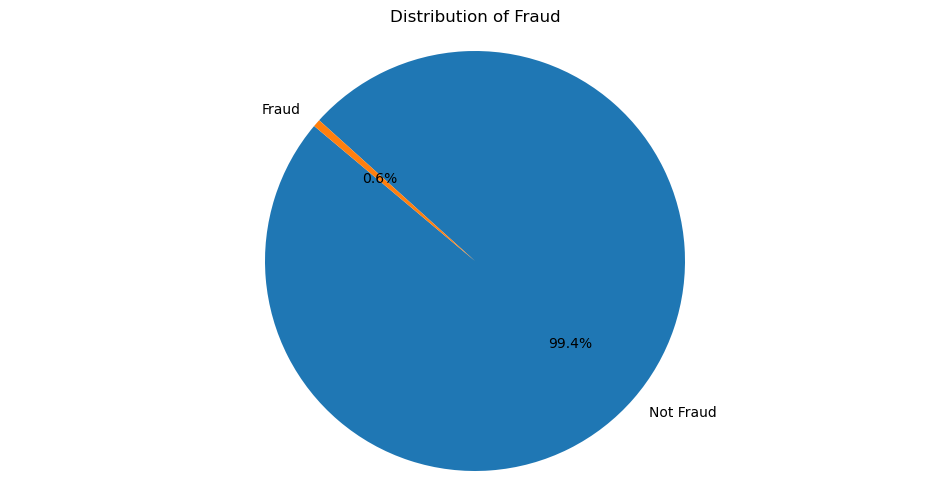

In [14]:
plt.figure(figsize = (12,6))
labels = ["Not Fraud","Fraud"]
values = df.is_fraud.value_counts()
plt.pie(values,labels = labels,autopct = "%1.1f%%",startangle = 140)
plt.title("Distribution of Fraud")
plt.axis("equal")
plt.show()

In [ ]:
df.groupby("is_fraud").count()["cc_num"].plot(kind = "bar")

In [ ]:
plt.figure(figsize=(20, 7))
ax = df[df['is_fraud'] == 1].groupby('dob').count()['is_fraud'].plot(kind='bar')
ax.set_xlabel('dob')
ax.set_ylabel('Count of Fraud Cases')
ax.set_title('Count of Fraud Cases by Age')
plt.xticks(rotation=45, ha='right')
plt.show()

In [ ]:
# Extract top 10 job titles associated with fraud and their counts
fraud_job_title = df[df["is_fraud"] == 1]["job"].value_counts().head(10)


# Convert to a DataFrame for easier plotting
fraud_job_title_df = fraud_job_title.reset_index()
fraud_job_title_df.columns = ['job', 'count']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=fraud_job_title_df, x="count", y="job",palette="viridis",dodge=False)
plt.title('Top 10 Job Titles Associated with Fraud')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.xticks(rotation=90)
plt.show()

In [ ]:
plt.figure(figsize = (12,6))
sns.countplot(x = "category",hue = "is_fraud",data = df,palette = "viridis")
plt.title("Category vs Fraud")
plt.xticks(rotation = 60)
plt.show()

In [ ]:
plt.figure(figsize = (12,6))
fraud_category = df[df["is_fraud"] == 1]["category"].value_counts()
sns.barplot(x = fraud_category.index,y = fraud_category.values, palette = "viridis")
plt.title("Category vs Fraud")
plt.xticks(rotation = 60)
plt.show()

In [ ]:
fraud_rate_by_state = df.groupby('state')['is_fraud'].count().sort_values(ascending=False).reset_index().head(10)

plt.figure(figsize=(15, 10))
sns.barplot(data=fraud_rate_by_state, x='is_fraud', y='state', palette='viridis')
plt.title('Fraud Rate by State')
plt.xlabel('Fraud Rate')
plt.ylabel('State')
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df[df['is_fraud'] == 1], x='long', y='lat', hue='is_fraud', palette='viridis', legend=False)
plt.title('Fraudulent Transaction Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [16]:
numeric_columns = [i for i in df.columns if df[i].dtype == 'int64' or df[i].dtype =='int32' or df[i].dtype =='float64']
categorical_columns = [i for i in df.columns if df[i].dtype == 'object']

In [18]:
encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2703186189652095,514,8,4.97,162,18,0,568,...,36.0788,-81.1781,3495,370,779,56438,1325376018,36.011293,-82.048315,0
1,1,1,630423337322,241,4,107.23,309,157,0,435,...,48.8878,-118.2105,149,428,607,159395,1325376044,49.159047,-118.186462,0
2,2,2,38859492057661,390,0,220.11,115,381,1,602,...,42.1808,-112.2620,4154,307,302,818703,1325376051,43.150704,-112.154481,0
3,3,3,3534093764340240,360,2,45.00,163,463,1,930,...,46.2306,-112.1138,1939,328,397,544575,1325376076,47.034331,-112.561071,0
4,4,4,375534208663984,297,9,41.96,336,149,1,418,...,38.4207,-79.4629,99,116,734,831111,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,1274786,30263540414123,499,0,15.56,121,332,1,154,...,37.7175,-112.4777,258,215,298,344658,1371816728,36.841266,-111.690765,0
1296671,1296671,1274787,6011149206456997,2,1,51.70,160,463,1,856,...,39.2667,-77.5101,100,360,630,199896,1371816739,38.906881,-78.246528,0
1296672,1296672,1274788,3514865930894695,599,1,105.93,74,67,1,158,...,32.9396,-105.8189,899,308,412,366013,1371816752,33.619513,-105.130529,0
1296673,1296673,1274789,2720012583106919,509,1,74.90,179,304,1,433,...,43.3526,-102.5411,1126,485,639,1086299,1371816816,42.788940,-103.241160,0


In [22]:
columns = df.columns.tolist() 
columns.remove('is_fraud')


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Feature Engineering

### Wrapper Method

In [26]:
corr_matrix = df.corr().abs()

In [28]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2703186189652095,514,8,4.97,162,18,0,568,...,36.0788,-81.1781,3495,370,779,56438,1325376018,36.011293,-82.048315,0
1,1,1,630423337322,241,4,107.23,309,157,0,435,...,48.8878,-118.2105,149,428,607,159395,1325376044,49.159047,-118.186462,0
2,2,2,38859492057661,390,0,220.11,115,381,1,602,...,42.1808,-112.2620,4154,307,302,818703,1325376051,43.150704,-112.154481,0
3,3,3,3534093764340240,360,2,45.00,163,463,1,930,...,46.2306,-112.1138,1939,328,397,544575,1325376076,47.034331,-112.561071,0
4,4,4,375534208663984,297,9,41.96,336,149,1,418,...,38.4207,-79.4629,99,116,734,831111,1325376186,38.674999,-78.632459,0


In [30]:
rs = np.random.RandomState(0)

corr = df.corr().abs()
corr.style.background_gradient(cmap='coolwarm')
# 'RdBu_r', 'BrBG_r', & PuOr_r are other good diverging colormaps

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
Unnamed: 0,1.000000,0.999999,0.000386,0.000972,0.000250,0.000251,0.000509,0.000121,0.000945,0.001067,0.000423,0.001048,0.000709,0.000602,0.000676,0.001678,0.000001,0.003712,0.000595,0.998971,0.000541,0.000671,0.004767
trans_date_trans_time,0.999999,1.000000,0.000385,0.000972,0.000249,0.000253,0.000509,0.000121,0.000946,0.001066,0.000424,0.001048,0.000709,0.000601,0.000676,0.001679,0.000000,0.003709,0.000596,0.999007,0.000540,0.000671,0.004777
cc_num,0.000386,0.000385,1.000000,0.000055,0.001230,0.001769,0.027189,0.006908,0.001112,0.046509,0.049188,0.036373,0.041459,0.059271,0.048278,0.008991,0.029165,0.002397,0.001415,0.000354,0.058942,0.048252,0.000981
merchant,0.000972,0.000972,0.000055,1.000000,0.032302,0.002633,0.001576,0.000439,0.000915,0.000718,0.000294,0.000424,0.001113,0.002266,0.000697,0.001911,0.001360,0.006798,0.000459,0.000999,0.002263,0.000673,0.000536
category,0.000250,0.000249,0.001230,0.032302,1.000000,0.030867,0.001931,0.004319,0.028259,0.002258,0.000784,0.000211,0.002371,0.008660,0.000767,0.009386,0.003490,0.004347,0.000356,0.000182,0.008519,0.000736,0.020205
amt,0.000251,0.000253,0.001769,0.002633,0.030867,1.000000,0.003575,0.004708,0.001034,0.001346,0.000565,0.001718,0.001843,0.001926,0.000187,0.005818,0.000628,0.010650,0.001297,0.000293,0.001873,0.000151,0.219404
first,0.000509,0.000509,0.027189,0.001576,0.001931,0.003575,1.000000,0.056983,0.015197,0.045369,0.009211,0.043145,0.004766,0.131869,0.016475,0.066607,0.039683,0.004203,0.000878,0.000483,0.130964,0.016489,0.003219
last,0.000121,0.000121,0.006908,0.000439,0.004319,0.004708,0.056983,1.000000,0.043740,0.005634,0.017553,0.048161,0.028295,0.034915,0.025557,0.012039,0.024596,0.019168,0.000153,0.000094,0.034548,0.025557,0.000096
gender,0.000945,0.000946,0.001112,0.000915,0.028259,0.001034,0.015197,0.043740,1.000000,0.042679,0.016039,0.031794,0.065951,0.042935,0.050404,0.028649,0.079908,0.012185,0.000289,0.000960,0.042645,0.050350,0.007642
street,0.001067,0.001066,0.046509,0.000718,0.002258,0.001346,0.045369,0.005634,0.042679,1.000000,0.024811,0.014045,0.053860,0.012651,0.071328,0.012530,0.020229,0.042514,0.001430,0.001089,0.012517,0.071286,0.001448


In [32]:
# Select upper triangle of correlation matrix
upper = corr.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

C:\Users\hp-Pc\AppData\Local\Temp\ipykernel_24272\861736515.py:2: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  upper = corr.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [34]:
# Find index of feature columns with correlation greater than 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

# Drop highly correlated features
X.drop(X[to_drop], axis=1, inplace=True)

print(X)

NameError: name 'upper' is not defined

In [36]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2703186189652095,514,8,4.97,162,18,0,568,...,36.0788,-81.1781,3495,370,779,56438,1325376018,36.011293,-82.048315,0
1,1,1,630423337322,241,4,107.23,309,157,0,435,...,48.8878,-118.2105,149,428,607,159395,1325376044,49.159047,-118.186462,0
2,2,2,38859492057661,390,0,220.11,115,381,1,602,...,42.1808,-112.2620,4154,307,302,818703,1325376051,43.150704,-112.154481,0
3,3,3,3534093764340240,360,2,45.00,163,463,1,930,...,46.2306,-112.1138,1939,328,397,544575,1325376076,47.034331,-112.561071,0
4,4,4,375534208663984,297,9,41.96,336,149,1,418,...,38.4207,-79.4629,99,116,734,831111,1325376186,38.674999,-78.632459,0


# Model Training

In [38]:
X = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']

X = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']


scaler = StandardScaler()

X[columns] = scaler.fit_transform(X[columns])
df[X.columns] = X
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,-1.732049,-1.734313,-0.316692,0.851654,0.452853,-0.407826,-0.187242,-1.701281,-0.909206,0.285529,...,-0.484420,0.657620,-0.282589,0.848099,0.915085,-1.581274,-1.858664,-0.494354,0.593864,0
1,-1.732047,-1.734310,-0.318757,-0.506880,-0.569266,0.230039,1.319929,-0.684263,-0.909206,-0.189368,...,2.039120,-2.033870,-0.293670,1.262061,0.272047,-1.306222,-1.858662,2.078699,-2.030341,0
2,-1.732044,-1.734307,-0.318728,0.234591,-1.591384,0.934149,-0.669126,0.954674,1.099861,0.406932,...,0.717754,-1.601537,-0.280406,0.398450,-0.868225,0.455137,-1.858662,0.902849,-1.592323,0
3,-1.732041,-1.734305,-0.316058,0.085302,-1.080325,-0.158132,-0.176989,1.554641,1.099861,1.578106,...,1.515617,-1.590766,-0.287742,0.548333,-0.513059,-0.277203,-1.858660,1.662886,-1.621848,0
4,-1.732039,-1.734302,-0.318471,-0.228206,0.708382,-0.177094,1.596756,-0.742796,1.099861,-0.250069,...,-0.023035,0.782279,-0.293835,-0.964771,0.746848,0.488286,-1.858651,0.026941,0.841909,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1.732039,1.732452,-0.318735,0.777010,-1.591384,-0.341769,-0.607609,0.596156,1.099861,-1.192721,...,-0.161575,-1.617214,-0.293309,-0.258180,-0.883180,-0.811286,1.757855,-0.331926,-1.558650,0
1296671,1.732041,1.732455,-0.314165,-1.696220,-1.335854,-0.116339,-0.207747,1.554641,1.099861,1.313878,...,0.143638,0.924207,-0.293832,0.776726,0.358034,-1.198022,1.757855,0.072321,0.869934,0
1296672,1.732044,1.732458,-0.316072,1.274641,-1.335854,0.221930,-1.089493,-1.342764,1.099861,-1.178439,...,-1.102883,-1.133257,-0.291186,0.405587,-0.456980,-0.754236,1.757856,-0.962433,-1.082272,0
1296673,1.732047,1.732461,-0.316680,0.826773,-1.335854,0.028375,-0.012943,0.391289,1.099861,-0.196509,...,0.948613,-0.895029,-0.290434,1.668887,0.391682,1.170027,1.757861,0.832051,-0.945074,0


In [40]:
# Assuming X is a DataFrame with datetime columns
# Remove datetime columns if they are not needed for modeling
#X = X.drop(columns=['dob'])  # Corrected syntax: drop(columns=['column_name'])

# Create RandomForestClassifier model
model_rfc = RandomForestClassifier(random_state=42, n_estimators=10, n_jobs=-1, max_depth=20)

# Fit the model
model_rfc.fit(X, y)


RandomForestClassifier(max_depth=20, n_estimators=10, n_jobs=-1,
                       random_state=42)

In [45]:
# Assuming you have already fitted the model and have the predictions
y_pred = model_rfc.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f'Accuracy Score: {accuracy}')

# Generate the classification report
report = classification_report(y_test, y_pred)

# Print the classification report
print('Classification Report:')
print(report)

Accuracy Score: 0.9990000077120228
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386718
           1       0.99      0.84      0.91      2285

    accuracy                           1.00    389003
   macro avg       1.00      0.92      0.95    389003
weighted avg       1.00      1.00      1.00    389003

